In [1]:
# Install CoolProp if it is missing (e.g., on Google Colab)
try:
    import CoolProp
except ImportError:
    %pip install -q CoolProp

import CoolProp.CoolProp as CP
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Configuration & Constants ---
fluids = ['Water', 'R134a', 'Air', 'Nitrogen', 'CO2', 'Ammonia', 'Ethanol', 'Methane']

# Input pairs (CoolProp Keys)
input_pairs = {
    'Temperature (K) & Pressure (Pa)': 'TP',
    'Temperature (K) & Quality (0-1)': 'TQ',
    'Pressure (Pa) & Quality (0-1)': 'PQ',
    'Pressure (Pa) & Enthalpy (J/kg)': 'PH',
    'Pressure (Pa) & Entropy (J/kg/K)': 'PS',
    'Temperature (K) & Density (kg/m3)': 'TD',
}

# --- 2. Helper Functions ---

def convert_units(data_dict, unit_system):
    """Converts a dictionary of SI properties to the target unit system."""
    d = data_dict.copy()
    
    if unit_system == 'SI':
        # Convert J to kJ for readability
        d['P'] = d['P [Pa]'] / 1000.0  # kPa
        d['T'] = d['T [K]']
        d['v'] = d['v [m3/kg]']
        d['u'] = d['u [J/kg]'] / 1000.0 # kJ/kg
        d['h'] = d['h [J/kg]'] / 1000.0 # kJ/kg
        d['s'] = d['s [J/kg/K]'] / 1000.0 # kJ/kg-K
        return d, {'P': 'kPa', 'T': 'K', 'v': 'm3/kg', 'u': 'kJ/kg', 'h': 'kJ/kg', 's': 'kJ/kg-K'}
    
    elif unit_system == 'Imperial':
        # Conversions
        d['P'] = d['P [Pa]'] * 0.000145038  # psia
        d['T'] = (d['T [K]'] - 273.15) * 1.8 + 32  # F
        d['v'] = d['v [m3/kg]'] * 16.0185  # ft3/lb
        d['u'] = d['u [J/kg]'] * 0.000429923  # Btu/lb
        d['h'] = d['h [J/kg]'] * 0.000429923  # Btu/lb
        d['s'] = d['s [J/kg/K]'] * 0.000238846 # Btu/lb-R
        return d, {'P': 'psia', 'T': 'F', 'v': 'ft3/lb', 'u': 'Btu/lb', 'h': 'Btu/lb', 's': 'Btu/lb-R'}

def get_phase_desc(fluid, T, P):
    try:
        T_crit = CP.PropsSI('Tcrit', fluid)
        P_crit = CP.PropsSI('Pcrit', fluid)
        
        if T > T_crit and P > P_crit:
            return "Supercritical"
        
        try:
            Psat = CP.PropsSI('P', 'T', T, 'Q', 0, fluid)
            if abs(P - Psat) < 1e-1: 
                return "Saturation"
            elif P > Psat:
                return "Compressed Liquid"
            else:
                return "Superheated Vapor"
        except:
             return "Fluid"
    except:
        return "Unknown"

def calculate_state(fluid, pair_key, val1, val2):
    inputs = {'TP': ('T', 'P'), 'TQ': ('T', 'Q'), 'PQ': ('P', 'Q'), 
              'PH': ('P', 'H'), 'PS': ('P', 'S'), 'TD': ('T', 'D')}
    
    param1_name, param2_name = inputs[pair_key]
    
    try:
        # Calculate in SI Base Units
        T = CP.PropsSI('T', param1_name, val1, param2_name, val2, fluid)
        P = CP.PropsSI('P', param1_name, val1, param2_name, val2, fluid)
        D = CP.PropsSI('D', param1_name, val1, param2_name, val2, fluid)
        H = CP.PropsSI('H', param1_name, val1, param2_name, val2, fluid)
        S = CP.PropsSI('S', param1_name, val1, param2_name, val2, fluid)
        U = CP.PropsSI('U', param1_name, val1, param2_name, val2, fluid)
        Q = CP.PropsSI('Q', param1_name, val1, param2_name, val2, fluid)
        v = 1.0 / D if D != 0 else 0
        
        if 0 <= Q <= 1:
            phase = f"Two-Phase (x={Q:.4f})"
        else:
            phase = get_phase_desc(fluid, T, P)
            Q = np.nan 
            
        return {
            'T [K]': T, 'P [Pa]': P, 'v [m3/kg]': v, 'u [J/kg]': U,
            'h [J/kg]': H, 's [J/kg/K]': S, 'Quality (x)': Q, 'Phase': phase
        }
    except Exception as e:
        return {'Error': str(e)}

# --- 3. Visualization Functions ---

def plot_diagrams(fluid, state1, state2, unit_system):
    """Plots both T-s and P-v diagrams side-by-side."""
    
    # Setup Data for Dome
    T_crit = CP.PropsSI('Tcrit', fluid)
    T_min = CP.PropsSI('Tmin', fluid)
    T_range = np.linspace(T_min, T_crit - 0.5, 50)
    
    # Calculate Saturation Lines (SI)
    s_liq_si = [CP.PropsSI('S', 'T', t, 'Q', 0, fluid) for t in T_range]
    s_vap_si = [CP.PropsSI('S', 'T', t, 'Q', 1, fluid) for t in T_range]
    v_liq_si = [1/CP.PropsSI('D', 'T', t, 'Q', 0, fluid) for t in T_range]
    v_vap_si = [1/CP.PropsSI('D', 'T', t, 'Q', 1, fluid) for t in T_range]
    p_sat_si = [CP.PropsSI('P', 'T', t, 'Q', 0, fluid) for t in T_range]
    
    # Convert Dome Data if needed
    if unit_system == 'Imperial':
        # T-s conversions
        T_plot = [(t - 273.15)*1.8 + 32 for t in T_range]
        s_liq = [s * 0.000238846 for s in s_liq_si]
        s_vap = [s * 0.000238846 for s in s_vap_si]
        # P-v conversions
        p_plot = [p * 0.000145038 for p in p_sat_si]
        v_liq = [v * 16.0185 for v in v_liq_si]
        v_vap = [v * 16.0185 for v in v_vap_si]
        
        units = {'T': 'F', 'P': 'psia', 'v': 'ft3/lb', 's': 'Btu/lb-R'}
    else:
        T_plot = T_range
        s_liq = [s/1000 for s in s_liq_si]
        s_vap = [s/1000 for s in s_vap_si]
        p_plot = [p/1000 for p in p_sat_si] # kPa
        v_liq = v_liq_si
        v_vap = v_vap_si
        units = {'T': 'K', 'P': 'kPa', 'v': 'm3/kg', 's': 'kJ/kg-K'}

    # Prepare Figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # --- Plot 1: T-s Diagram ---
    ax1.plot(s_liq, T_plot, 'k-', alpha=0.5, label='Sat. Liq')
    ax1.plot(s_vap, T_plot, 'k--', alpha=0.5, label='Sat. Vap')
    ax1.set_xlabel(f"Entropy ({units['s']})")
    ax1.set_ylabel(f"Temperature ({units['T']})")
    ax1.set_title(f"T-s Diagram ({fluid})")
    
    # --- Plot 2: P-v Diagram ---
    ax2.plot(v_liq, p_plot, 'k-', alpha=0.5)
    ax2.plot(v_vap, p_plot, 'k--', alpha=0.5)
    ax2.set_xlabel(f"Specific Volume ({units['v']})")
    ax2.set_ylabel(f"Pressure ({units['P']})")
    ax2.set_xscale('log') # Log scale for volume is essential
    ax2.set_title(f"P-v Diagram ({fluid})")

    # Plot Points
    for state, color, label in [(state1, 'r', '1'), (state2, 'b', '2')]:
        if 'Error' not in state:
            # Convert single state point
            s_conv, _ = convert_units(state, unit_system)
            
            # T-s Point
            ax1.plot(s_conv['s'], s_conv['T'], marker='o', color=color, label=f"State {label}")
            
            # P-v Point
            ax2.plot(s_conv['v'], s_conv['P'], marker='o', color=color, label=f"State {label}")

    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.grid(True, alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()

# --- 4. Interface & Logic ---

w_fluid = widgets.Dropdown(options=fluids, value='Water', description='Fluid:')
w_units = widgets.ToggleButtons(options=['SI', 'Imperial'], value='SI', description='Output Units:')

# State 1 Widgets
w_pair1 = widgets.Dropdown(options=input_pairs, value='TP', description='State 1 Inputs:')
w_val1_1 = widgets.FloatText(description='Prop 1:', value=300)
w_val1_2 = widgets.FloatText(description='Prop 2:', value=101325)

# State 2 Widgets
w_pair2 = widgets.Dropdown(options=input_pairs, value='TP', description='State 2 Inputs:')
w_val2_1 = widgets.FloatText(description='Prop 1:', value=400)
w_val2_2 = widgets.FloatText(description='Prop 2:', value=101325)

btn_calc = widgets.Button(description='Calculate', button_style='primary')
out_display = widgets.Output()

def on_calc_clicked(b):
    with out_display:
        clear_output()
        
        # Calculate Base States (SI)
        s1 = calculate_state(w_fluid.value, w_pair1.value, w_val1_1.value, w_val1_2.value)
        s2 = calculate_state(w_fluid.value, w_pair2.value, w_val2_1.value, w_val2_2.value)
        
        if 'Error' in s1: print(f"Error State 1: {s1['Error']}"); return
        if 'Error' in s2: print(f"Error State 2: {s2['Error']}"); return

        # Convert for Display
        sys = w_units.value
        s1_disp, u_labels = convert_units(s1, sys)
        s2_disp, _ = convert_units(s2, sys)
        
        # Create Table Data
        props = ['T', 'P', 'v', 'u', 'h', 's']
        prop_names = [f"Temperature [{u_labels['T']}]", f"Pressure [{u_labels['P']}]", 
                      f"Spec. Vol [{u_labels['v']}]", f"Int. Energy [{u_labels['u']}]", 
                      f"Enthalpy [{u_labels['h']}]", f"Entropy [{u_labels['s']}]"]
        
        data = {'Property': prop_names + ['Quality (x)', 'Phase']}
        data['State 1'] = [s1_disp[p] for p in props] + [s1['Quality (x)'], s1['Phase']]
        data['State 2'] = [s2_disp[p] for p in props] + [s2['Quality (x)'], s2['Phase']]
        
        df = pd.DataFrame(data)
        
        # Calculate Delta
        deltas = []
        for i in range(len(props)):
            deltas.append(data['State 2'][i] - data['State 1'][i])
        deltas.extend(['', '']) # No delta for Q or Phase
        df['Delta (2-1)'] = deltas
        
        # Display Table
        display(df.style.format(precision=4, subset=['State 1', 'State 2', 'Delta (2-1)']))
        
        # Plot Diagrams
        plot_diagrams(w_fluid.value, s1, s2, sys)
        
        # Reference State Note
        display(widgets.HTML(f"""
        <div style="background-color: #e7f3fe; border-left: 6px solid #2196F3; padding: 10px; margin-top: 10px;">
        <strong>Important Note on Reference States:</strong><br>
        Values for Energy (u, h) and Entropy (s) are calculated relative to a reference state where h=0 and s=0. 
        CoolProp often uses the IIR standard (saturated liquid at 0°C) or NBP (Normal Boiling Point) depending on the fluid. 
        <br><strong>Warning:</strong> The <em>absolute</em> values shown here may differ from your textbook tables if the reference states do not match. 
        However, the <strong>Difference (Delta)</strong> values should match closely, as differences are independent of the reference state.
        </div>
        """))

btn_calc.on_click(on_calc_clicked)

# Layout
ui = widgets.VBox([
    widgets.HTML("<h2>Thermodynamic Property Calculator</h2>"),
    widgets.HBox([w_fluid, w_units]),
    widgets.HTML("<i><b>Note:</b> Please enter input values in SI Units (K, Pa, J/kg). Output will convert based on toggle.</i>"),
    widgets.HTML("<hr>"),
    widgets.HBox([
        widgets.VBox([widgets.HTML("<b>State 1</b>"), w_pair1, w_val1_1, w_val1_2]),
        widgets.VBox([widgets.HTML("<b>State 2</b>"), w_pair2, w_val2_1, w_val2_2])
    ]),
    widgets.HTML("<br>"),
    btn_calc,
    out_display
])

display(ui)

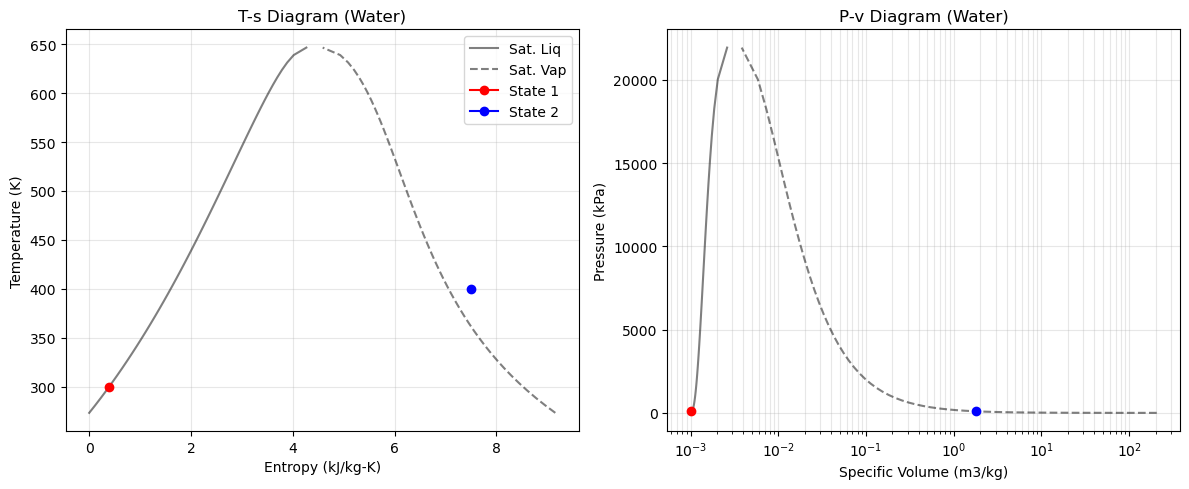

In [ ]:
# Static preview: results for the default inputs above.
# The output is saved so the course website can show it.
# To try other inputs, use the controls above, or open
# this notebook in Colab (badge on the course website).
s1 = calculate_state(w_fluid.value, w_pair1.value, w_val1_1.value, w_val1_2.value)
s2 = calculate_state(w_fluid.value, w_pair2.value, w_val2_1.value, w_val2_2.value)
plot_diagrams(w_fluid.value, s1, s2, w_units.value)